Low-frequency subtype merging summary

ADC
  Total count: 17929
  Cutoff: 35.86
  Merged into Others: 77
  Subtypes: ADC-1, ADC-15, ADC-19, ADC-21, ADC-31, ADC-39, ADC-4, ADC-41, ADC-61, ADC-78

CARB
  Total count: 491
  Cutoff: 0.98
  No rare subtypes merged.

NDM
  Total count: 968
  Cutoff: 1.94
  Merged into Others: 2
  Subtypes: NDM-4, NDM-6

OXA
  Total count: 19845
  Cutoff: 39.69
  Merged into Others: 970
  Subtypes: OXA-107, OXA-111, OXA-122, OXA-123, OXA-125, OXA-127, OXA-128, OXA-130, OXA-131, OXA-132, OXA-144, OXA-148, OXA-150, OXA-172, OXA-179, OXA-200, OXA-201, OXA-202, OXA-206, OXA-219, OXA-223, OXA-23, OXA-24, OXA-241, OXA-242, OXA-250, OXA-254, OXA-260, OXA-261, OXA-262, OXA-263, OXA-312, OXA-314, OXA-316, OXA-317, OXA-336, OXA-337, OXA-338, OXA-339, OXA-340, OXA-341, OXA-342, OXA-344, OXA-345, OXA-346, OXA-365, OXA-371, OXA-374, OXA-375, OXA-376, OXA-377, OXA-378, OXA-379, OXA-380, OXA-381, OXA-382, OXA-383, OXA-384, OXA-385, OXA-386, OXA-387, OXA-388, OXA-389, OXA-39

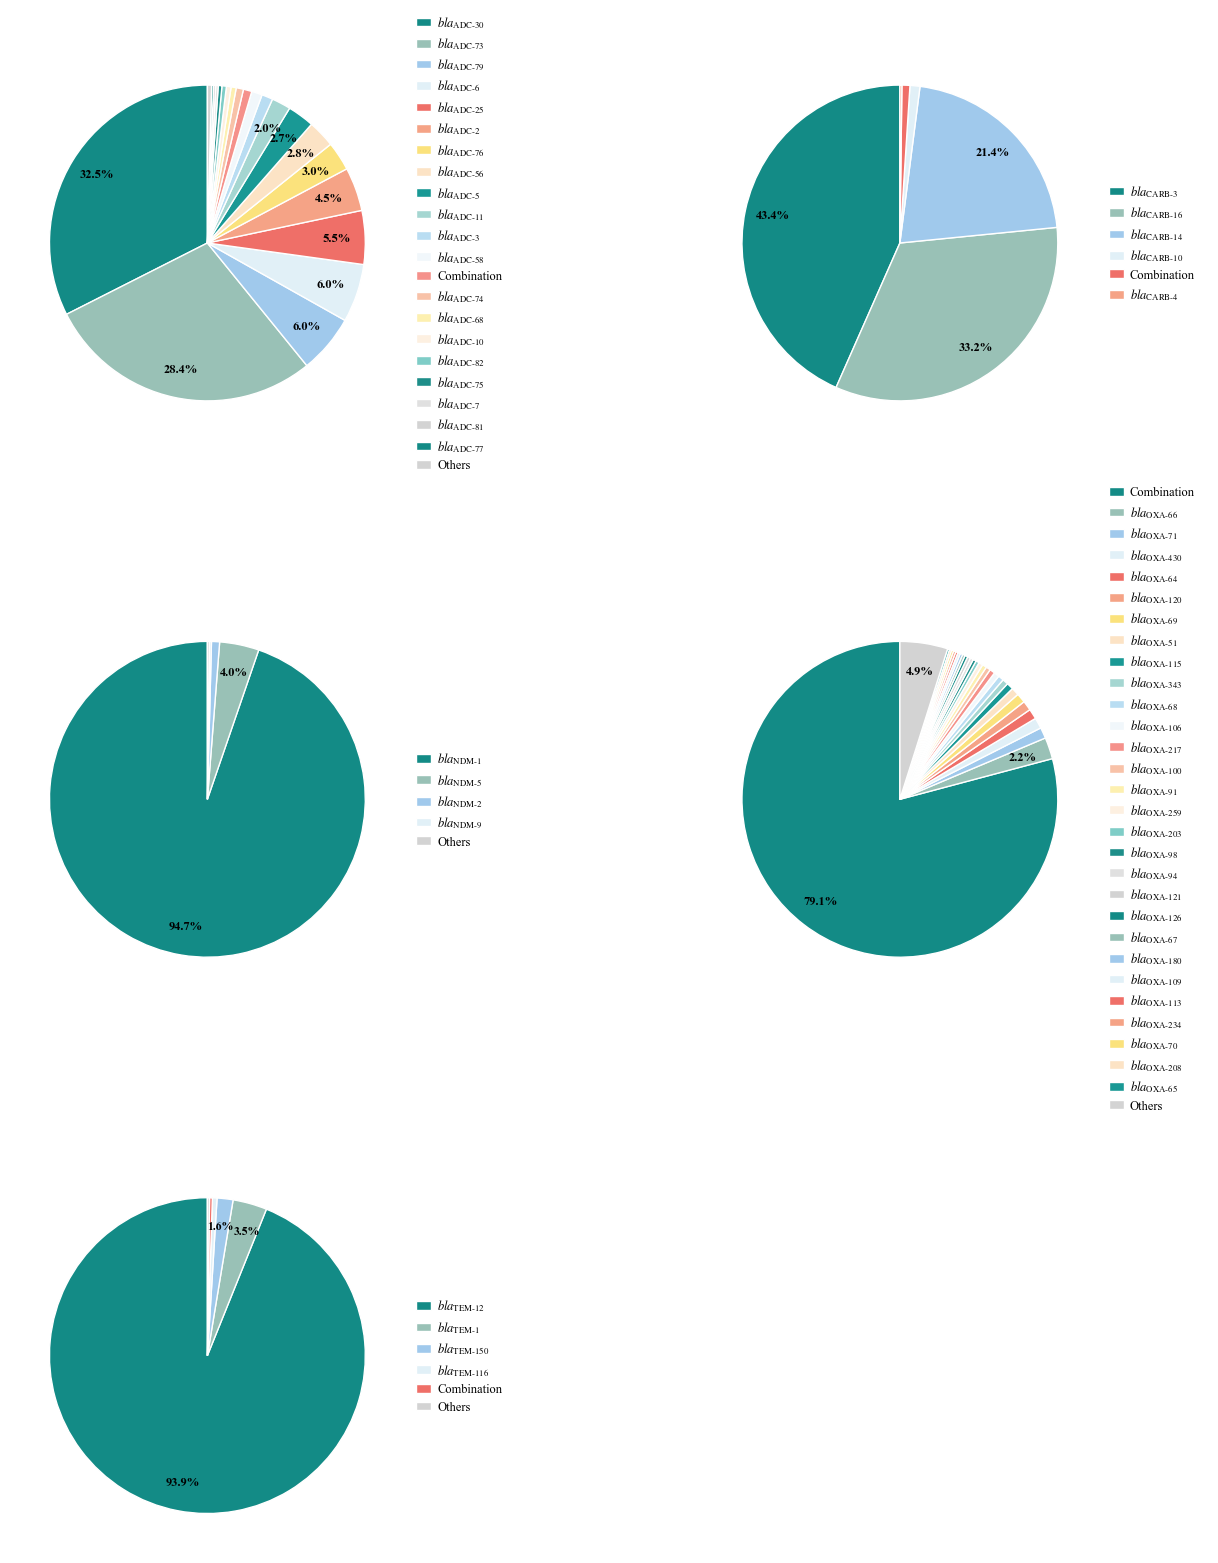


Plot completed!
Saved as: D:\python\敏感性分析\第二部分\Variant_Pie_Charts.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


# ============================================================
# 1. 基本参数
# ============================================================

# 输入文件
input_file = r"D:\A.baumannii\data\resistance_gene_counts.csv"

# 输出图片
output_file = "Variant_Pie_Charts.png"

# 基因家族绘图顺序
family_order = [
    "ADC",
    "CARB",
    "NDM",
    "OXA",
    "TEM"
]


# ============================================================
# 2. 低频亚型合并阈值
#
# 0.002 = 0.2%
#
# 某个亚型数量 / 当前家族总数量 < 0.2%
# 时，将其归入 Others。
#
# Combination 始终单独保留。
# ============================================================

MIN_RATIO = 0.002


# ============================================================
# 3. 百分比显示阈值
#
# > 1.5% 才显示百分比
# ============================================================

SHOW_PERCENT_ABOVE = 1.5


# ============================================================
# 4. TEM 小比例百分比位置参数
#
# 1.6% 和 3.5% 使用相同半径，
# 使二者距离圆心保持一致。
# ============================================================

TEM_SMALL_RADIUS = 0.82

# 3.5%稍微向右移动
# 负值 = 顺时针移动
TEM_35_SHIFT = -2.0

# 1.6%稍微向左移动
TEM_16_SHIFT = 0.5


# ============================================================
# 5. 亚型中横杠设置
#
# 注意：
# 这里不是普通键盘上的 "-"
#
# 而是 Unicode 短连字符：
#
# ‐
#
# U+2010 HYPHEN
#
# 与数学减号相比明显更短。
# ============================================================

SHORT_HYPHEN = "‐"


# ============================================================
# 6. 字体设置
# ============================================================

plt.rcParams["font.family"] = "Times New Roman"

# 数学文字使用 STIX
plt.rcParams["mathtext.fontset"] = "stix"

plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 7. 读取 CSV
# ============================================================

df = pd.read_csv(input_file)


# ============================================================
# 8. 检查输入列
# ============================================================

required_columns = {
    "Gene_Family",
    "Type",
    "Count"
}

if not required_columns.issubset(df.columns):

    raise ValueError(
        "输入文件必须包含以下三列："
        "Gene_Family, Type, Count"
    )


# ============================================================
# 9. 数据清理
# ============================================================

# 基因家族统一为大写
df["Gene_Family"] = (
    df["Gene_Family"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# 清理 Type
df["Type"] = (
    df["Type"]
    .astype(str)
    .str.strip()
)

# Count 转换为数值
df["Count"] = pd.to_numeric(
    df["Count"],
    errors="coerce"
)

# 删除无效数据
df = df.dropna(
    subset=[
        "Gene_Family",
        "Type",
        "Count"
    ]
)

df["Count"] = df["Count"].astype(int)


# ============================================================
# 10. Others 名称统一
#
# others / other / Others
# 全部统一为 Others
# ============================================================

df["Type"] = df["Type"].apply(
    lambda x:
    "Others"
    if str(x).strip().lower()
    in ["others", "other"]
    else x
)


# ============================================================
# 11. 如果同一亚型重复出现，则合并求和
# ============================================================

df = (
    df.groupby(
        [
            "Gene_Family",
            "Type"
        ],
        as_index=False
    )["Count"]
    .sum()
)


# ============================================================
# 12. 低频亚型合并函数
# ============================================================

def merge_rare_types(group_df, min_ratio=0.002):

    group_df = group_df.copy()

    # 当前家族总数量
    total_count = group_df["Count"].sum()

    # 低频数量阈值
    cutoff = total_count * min_ratio

    # 不参与低频合并的特殊类型
    special_types = [
        "Combination",
        "Others"
    ]

    # 判断低频亚型
    rare_mask = (
        (group_df["Count"] < cutoff)
        &
        (~group_df["Type"].isin(special_types))
    )

    # 被合并的亚型
    rare_df = group_df.loc[
        rare_mask
    ].copy()

    # 被合并亚型数量总和
    rare_count = rare_df["Count"].sum()

    # 保留其他类型
    result = group_df.loc[
        ~rare_mask
    ].copy()


    # --------------------------------------------------------
    # 将低频亚型加入 Others
    # --------------------------------------------------------

    if rare_count > 0:

        # 原数据已经存在 Others
        if "Others" in result["Type"].values:

            result.loc[
                result["Type"] == "Others",
                "Count"
            ] += rare_count

        # 原数据没有 Others
        else:

            new_row = pd.DataFrame(
                {
                    "Gene_Family": [
                        group_df["Gene_Family"].iloc[0]
                    ],

                    "Type": [
                        "Others"
                    ],

                    "Count": [
                        rare_count
                    ]
                }
            )

            result = pd.concat(
                [
                    result,
                    new_row
                ],
                ignore_index=True
            )


    # --------------------------------------------------------
    # 排序
    #
    # 普通亚型按数量降序
    # Others 固定放最后
    # --------------------------------------------------------

    others_df = result[
        result["Type"] == "Others"
    ]

    main_df = result[
        result["Type"] != "Others"
    ].sort_values(
        "Count",
        ascending=False
    )

    result = pd.concat(
        [
            main_df,
            others_df
        ],
        ignore_index=True
    )

    return result, cutoff, rare_df


# ============================================================
# 13. 处理所有基因家族
# ============================================================

plot_data = {}

print("=" * 70)
print("Low-frequency subtype merging summary")
print("=" * 70)


for family in family_order:

    family_df = df[
        df["Gene_Family"] == family
    ].copy()


    if family_df.empty:

        print(
            f"\n{family}: no data"
        )

        continue


    processed_df, cutoff, rare_df = merge_rare_types(
        family_df,
        MIN_RATIO
    )

    plot_data[family] = processed_df

    total = family_df["Count"].sum()


    print(
        f"\n{family}"
    )

    print(
        f"  Total count: {total}"
    )

    print(
        f"  Cutoff: {cutoff:.2f}"
    )


    if len(rare_df) > 0:

        print(
            f"  Merged into Others: "
            f"{rare_df['Count'].sum()}"
        )

        print(
            "  Subtypes: "
            + ", ".join(
                rare_df["Type"].tolist()
            )
        )

    else:

        print(
            "  No rare subtypes merged."
        )


# ============================================================
# 14. 配色
# ============================================================

colors = [

    "#138B86",

    "#99C1B6",

    "#A0C9EC",

    "#E1F0F7",

    "#EF6F68",

    "#F5A386",

    "#FBE27C",

    "#FCE3C5",

    "#199995",

    "#A5D6D1",

    "#B9DDF2",

    "#F1F7FB",

    "#F5918B",

    "#F8C2A8",

    "#FDF0B0",

    "#FDF0E1",

    "#7FCDC7",

    "#1E8E89",

    "#E0E0E0",

    "#D3D3D3"

] * 5


# ============================================================
# 15. 格式化图例中的基因名称
#
# 原始：
# ADC-73
#
# 图中：
# bla_ADC‐73
#
# 其中：
# bla       = 斜体
# ADC‐73    = 正体下标
#
# 关键变化：
# 使用短连字符 "‐"
# 而不是数学减号 "-"
# ============================================================

def format_label(name):

    # Combination 保持普通字体
    if name == "Combination":
        return "Combination"

    # Others 保持普通字体
    if name == "Others":
        return "Others"


    # --------------------------------------------------------
    # 匹配：
    #
    # ADC-73
    # OXA-66
    # TEM-12
    # NDM-1
    # CARB-3
    # --------------------------------------------------------

    match = re.match(
        r"^([A-Za-z]+)-(.+)$",
        str(name)
    )


    if match:

        gene_family = match.group(1)

        subtype = match.group(2)


        # ----------------------------------------------------
        # 使用 Unicode U+2010 短连字符
        #
        # 例如：
        #
        # ADC‐73
        #
        # 而不是：
        #
        # ADC-73
        #
        # 后者在数学模式中容易显示成较长的减号。
        # ----------------------------------------------------

        gene_text = (
            gene_family
            + SHORT_HYPHEN
            + subtype
        )


        return (
            rf"$\mathit{{bla}}_"
            rf"{{\mathrm{{{gene_text}}}}}$"
        )


    return str(name)


# ============================================================
# 16. 百分比显示函数
# ============================================================

def autopct_func(pct):

    if pct > SHOW_PERCENT_ABOVE:

        return f"{pct:.1f}%"

    return ""


# ============================================================
# 17. 创建画布
#
# ADC        CARB
#
# NDM        OXA
#
# TEM        空白
#
# 不显示子图编号
# 不显示基因家族标题
# ============================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 16)
)

axes = axes.flatten()


# ============================================================
# 18. 绘制饼图
# ============================================================

for i, family in enumerate(family_order):

    ax = axes[i]


    # --------------------------------------------------------
    # 如果没有该家族数据
    # --------------------------------------------------------

    if family not in plot_data:

        ax.axis("off")

        continue


    family_df = plot_data[family]


    labels = family_df[
        "Type"
    ].tolist()


    sizes = family_df[
        "Count"
    ].tolist()


    total = sum(sizes)


    # --------------------------------------------------------
    # 格式化图例名称
    # --------------------------------------------------------

    formatted_labels = [
        format_label(label)
        for label in labels
    ]


    # ========================================================
    # 设置颜色
    #
    # Others 固定为灰色
    # ========================================================

    pie_colors = []

    normal_color_index = 0


    for label in labels:

        if label == "Others":

            pie_colors.append(
                "#D3D3D3"
            )

        else:

            pie_colors.append(
                colors[
                    normal_color_index
                    % len(colors)
                ]
            )

            normal_color_index += 1


    # ========================================================
    # 绘制饼图
    # ========================================================

    wedges, texts, autotexts = ax.pie(

        sizes,

        colors=pie_colors,

        autopct=autopct_func,

        # 12点方向开始
        startangle=90,

        # 默认百分比位置
        pctdistance=0.82,

        # 扇区白色边界
        wedgeprops=dict(
            edgecolor="white",
            linewidth=1
        ),

        # 百分比文字
        textprops={
            "fontweight": "bold",
            "fontsize": 10
        }
    )


    # ========================================================
    # 百分比字体设置
    # ========================================================

    for autotext in autotexts:

        autotext.set_fontsize(9)

        autotext.set_fontweight(
            "bold"
        )


    # ========================================================
    # TEM小比例百分比位置特殊调整
    #
    # 目标：
    #
    # 1.6% 与 3.5%
    # 距离圆心保持一致
    #
    # 3.5%稍微向右移动
    # 1.6%稍微向左移动
    #
    # 只调整角度，不改变半径
    # ========================================================

    if family == "TEM":

        for j, (
            wedge,
            autotext
        ) in enumerate(
            zip(
                wedges,
                autotexts
            )
        ):


            # ------------------------------------------------
            # 当前扇区百分比
            # ------------------------------------------------

            pct = (
                sizes[j]
                / total
                * 100
            )


            # 未显示的比例不处理
            if pct <= SHOW_PERCENT_ABOVE:

                continue


            # ------------------------------------------------
            # 当前扇区中心角
            # ------------------------------------------------

            angle = (
                wedge.theta1
                +
                wedge.theta2
            ) / 2


            # ------------------------------------------------
            # 1.6%
            #
            # 稍微向左
            # ------------------------------------------------

            if round(pct, 1) == 1.6:

                angle += TEM_16_SHIFT

                radius = TEM_SMALL_RADIUS


            # ------------------------------------------------
            # 3.5%
            #
            # 稍微向右
            # ------------------------------------------------

            elif round(pct, 1) == 3.5:

                angle += TEM_35_SHIFT

                radius = TEM_SMALL_RADIUS


            # ------------------------------------------------
            # TEM中其他小于5%的比例
            #
            # 保持同样半径
            # ------------------------------------------------

            elif pct < 5:

                radius = TEM_SMALL_RADIUS


            # ------------------------------------------------
            # 大比例不调整
            # ------------------------------------------------

            else:

                continue


            # ------------------------------------------------
            # 角度转换为弧度
            # ------------------------------------------------

            angle_rad = np.deg2rad(
                angle
            )


            # ------------------------------------------------
            # 计算坐标
            # ------------------------------------------------

            x = (
                radius
                *
                np.cos(angle_rad)
            )

            y = (
                radius
                *
                np.sin(angle_rad)
            )


            # ------------------------------------------------
            # 设置新位置
            # ------------------------------------------------

            autotext.set_position(
                (x, y)
            )


            # 小比例字体稍小
            autotext.set_fontsize(
                8.5
            )


    # ========================================================
    # 图例
    # ========================================================

    ax.legend(

        wedges,

        formatted_labels,

        loc="center left",

        bbox_to_anchor=(
            1.00,
            0,
            0.5,
            1
        ),

        frameon=False,

        fontsize=9,

        handlelength=1.2,

        handletextpad=0.5,

        labelspacing=0.45
    )


# ============================================================
# 19. 隐藏第6个空白子图
# ============================================================

axes[-1].axis(
    "off"
)


# ============================================================
# 20. 调整布局
# ============================================================

plt.subplots_adjust(
    wspace=0.55,
    hspace=0.30
)

plt.tight_layout()


# ============================================================
# 21. 保存图片
# ============================================================

plt.savefig(

    output_file,

    dpi=300,

    bbox_inches="tight"
)


# ============================================================
# 22. 显示图片
# ============================================================

plt.show()


# ============================================================
# 23. 完成提示
# ============================================================

print("\nPlot completed!")

print(
    f"Saved as: {output_file}"
)